### 네이버와 구글 서버 헤더 정보 비교

먼저 `requests` 라이브러리를 임포트합니다. 이 라이브러리는 웹 페이지에 HTTP 요청을 보내고 응답을 받을 수 있게 해줍니다.

# 공부하기

In [4]:
import requests

#### 네이버 서버 헤더 정보 가져오기

네이버 웹사이트에 GET 요청을 보내고, 응답 헤더 정보를 출력합니다.

In [13]:
naver_response = requests.get('https://www.naver.com') # x =1

In [15]:
naver_response.json()

JSONDecodeError: Expecting value: line 1 column 4 (char 3)

In [8]:
naver_response.headers.items()

ItemsView({'Content-Type': 'text/html; charset=UTF-8', 'Cache-Control': 'no-cache, no-store, must-revalidate', 'Pragma': 'no-cache', 'x-frame-options': 'DENY', 'x-xss-protection': '1; mode=block', 'strict-transport-security': 'max-age=63072000; includeSubdomains', 'referrer-policy': 'unsafe-url', 'Content-Encoding': 'gzip', 'Server': 'nfront', 'Content-Length': '30321', 'Date': 'Fri, 27 Mar 2026 03:17:22 GMT', 'Connection': 'keep-alive', 'Vary': 'Accept-Encoding'})

In [12]:
try:
    naver_response = requests.get('https://www.naver.com')
    print('--- 네이버 서버 헤더 정보 ---')
    for header, value in naver_response.headers.items():
        print(f'{header}: {value}')
except requests.exceptions.RequestException as e:
    print(f"네이버 서버에 연결하는 중 오류가 발생했습니다: {e}")

--- 네이버 서버 헤더 정보 ---
Content-Type: text/html; charset=UTF-8
Cache-Control: no-cache, no-store, must-revalidate
Pragma: no-cache
x-frame-options: DENY
x-xss-protection: 1; mode=block
strict-transport-security: max-age=63072000; includeSubdomains
referrer-policy: unsafe-url
Content-Encoding: gzip
Server: nfront
Content-Length: 30100
Date: Fri, 27 Mar 2026 03:28:11 GMT
Connection: keep-alive
Vary: Accept-Encoding


#### 구글 서버 헤더 정보 가져오기

구글 웹사이트에 GET 요청을 보내고, 응답 헤더 정보를 출력합니다.

In [3]:
try:
    google_response = requests.get('https://www.google.com')
    print('\n--- 구글 서버 헤더 정보 ---')
    for header, value in google_response.headers.items():
        print(f'{header}: {value}')
except requests.exceptions.RequestException as e:
    print(f"구글 서버에 연결하는 중 오류가 발생했습니다: {e}")


--- 구글 서버 헤더 정보 ---
Date: Fri, 27 Mar 2026 03:16:12 GMT
Expires: -1
Cache-Control: private, max-age=0
Content-Type: text/html; charset=ISO-8859-1
Content-Security-Policy-Report-Only: object-src 'none';base-uri 'self';script-src 'nonce-TT_bSxXsWiELFdfLHkqaMg' 'strict-dynamic' 'report-sample' 'unsafe-eval' 'unsafe-inline' https: http:;report-uri https://csp.withgoogle.com/csp/gws/other-hp
Reporting-Endpoints: default="//www.google.com/httpservice/retry/jserror?ei=fPbFae7MCpLL0PEP1Zfu8AM&cad=crash&error=Page%20Crash&jsel=1&bver=2411&dpf=eyZi43akdqVkvT6mz17wXG3bV3Sde8s-RTE18xOsqnM"
Accept-CH: Sec-CH-Prefers-Color-Scheme
P3P: CP="This is not a P3P policy! See g.co/p3phelp for more info."
Content-Encoding: gzip
Server: gws
X-XSS-Protection: 0
X-Frame-Options: SAMEORIGIN
Set-Cookie: __Secure-STRP=AEEP7gIHViBwZZIS74flUyIJAwx1F92KqShsTeCo13brtW37-mbiQBWtQN0E_QZbQLvKowyZRMcGnvS3Jp6ryq_8Uof8H49QLA; expires=Fri, 27-Mar-2026 03:21:12 GMT; path=/; domain=.google.com; Secure; SameSite=strict, AEC=Aa

In [10]:
import requests
import pandas as pd

url = "https://jsonplaceholder.typicode.com/users"

try:
    # 1. requests 모듈로 JSON 파일 불러오기
    response = requests.get(url)
    response.raise_for_status() # HTTP 오류가 발생하면 예외를 발생시킵니다.
    json_data = response.json()

    # 2. 불러온 데이터를 데이터프레임으로 저장
    df_users = pd.DataFrame(json_data)
    print("--- 원본 데이터프레임 (df_users) ---")
    print(df_users.head())
    print("\n")

    # 3. 컬럼명(변수명)이 'address'인 series의 내용을 데이터프레임으로 변경
    # 'address' 컬럼이 중첩된 JSON 형태이므로 json_normalize를 사용합니다.
    df_address = pd.json_normalize(df_users['address'])
    print("--- 'address' 컬럼을 데이터프레임으로 변경 (df_address) ---")
    print(df_address.head())
    print("\n")

    # 원본 데이터프레임에서 'address' 컬럼 제거 후, 정규화된 주소 정보를 병합할 수도 있습니다.
    # df_users_processed = df_users.drop(columns=['address'])
    # df_final = pd.concat([df_users_processed, df_address], axis=1)
    # print("--- address 컬럼을 정규화하여 병합한 최종 데이터프레임 ---")
    # print(df_final.head())

except requests.exceptions.RequestException as e:
    print(f"API 요청 중 오류가 발생했습니다: {e}")
except Exception as e:
    print(f"데이터 처리 중 오류가 발생했습니다: {e}")

--- 원본 데이터프레임 (df_users) ---
   id              name   username                      email  \
0   1     Leanne Graham       Bret          Sincere@april.biz   
1   2      Ervin Howell  Antonette          Shanna@melissa.tv   
2   3  Clementine Bauch   Samantha         Nathan@yesenia.net   
3   4  Patricia Lebsack   Karianne  Julianne.OConner@kory.org   
4   5  Chelsey Dietrich     Kamren   Lucio_Hettinger@annie.ca   

                                             address                  phone  \
0  {'street': 'Kulas Light', 'suite': 'Apt. 556',...  1-770-736-8031 x56442   
1  {'street': 'Victor Plains', 'suite': 'Suite 87...    010-692-6593 x09125   
2  {'street': 'Douglas Extension', 'suite': 'Suit...         1-463-123-4447   
3  {'street': 'Hoeger Mall', 'suite': 'Apt. 692',...      493-170-9623 x156   
4  {'street': 'Skiles Walks', 'suite': 'Suite 351...          (254)954-1289   

         website                                            company  
0  hildegard.org  {'name': 'Romague

In [16]:
df_users

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."
5,6,Mrs. Dennis Schulist,Leopoldo_Corkery,Karley_Dach@jasper.info,"{'street': 'Norberto Crossing', 'suite': 'Apt....",1-477-935-8478 x6430,ola.org,"{'name': 'Considine-Lockman', 'catchPhrase': '..."
6,7,Kurtis Weissnat,Elwyn.Skiles,Telly.Hoeger@billy.biz,"{'street': 'Rex Trail', 'suite': 'Suite 280', ...",210.067.6132,elvis.io,"{'name': 'Johns Group', 'catchPhrase': 'Config..."
7,8,Nicholas Runolfsdottir V,Maxime_Nienow,Sherwood@rosamond.me,"{'street': 'Ellsworth Summit', 'suite': 'Suite...",586.493.6943 x140,jacynthe.com,"{'name': 'Abernathy Group', 'catchPhrase': 'Im..."
8,9,Glenna Reichert,Delphine,Chaim_McDermott@dana.io,"{'street': 'Dayna Park', 'suite': 'Suite 449',...",(775)976-6794 x41206,conrad.com,"{'name': 'Yost and Sons', 'catchPhrase': 'Swit..."
9,10,Clementina DuBuque,Moriah.Stanton,Rey.Padberg@karina.biz,"{'street': 'Kattie Turnpike', 'suite': 'Suite ...",024-648-3804,ambrose.net,"{'name': 'Hoeger LLC', 'catchPhrase': 'Central..."


In [17]:
df_address

,street,suite,city,zipcode,geo.lat,geo.lng
0,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496
1,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618
2,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653
3,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990
4,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342
5,Norberto Crossing,Apt. 950,South Christy,23505-1337,-71.4197,71.7478
6,Rex Trail,Suite 280,Howemouth,58804-1099,24.8918,21.8984
7,Ellsworth Summit,Suite 729,Aliyaview,45169,-14.3990,-120.7677
8,Dayna Park,Suite 449,Bartholomebury,76495-3109,24.6463,-168.8889
9,Kattie Turnpike,Suite 198,Lebsackbury,31428-2261,-38.2386,57.2232


In [18]:
print(df_address.to_json(orient='records', indent=4))

[
    {
        "street":"Kulas Light",
        "suite":"Apt. 556",
        "city":"Gwenborough",
        "zipcode":"92998-3874",
        "geo.lat":"-37.3159",
        "geo.lng":"81.1496"
    },
    {
        "street":"Victor Plains",
        "suite":"Suite 879",
        "city":"Wisokyburgh",
        "zipcode":"90566-7771",
        "geo.lat":"-43.9509",
        "geo.lng":"-34.4618"
    },
    {
        "street":"Douglas Extension",
        "suite":"Suite 847",
        "city":"McKenziehaven",
        "zipcode":"59590-4157",
        "geo.lat":"-68.6102",
        "geo.lng":"-47.0653"
    },
    {
        "street":"Hoeger Mall",
        "suite":"Apt. 692",
        "city":"South Elvis",
        "zipcode":"53919-4257",
        "geo.lat":"29.4572",
        "geo.lng":"-164.2990"
    },
    {
        "street":"Skiles Walks",
        "suite":"Suite 351",
        "city":"Roscoeview",
        "zipcode":"33263",
        "geo.lat":"-31.8129",
        "geo.lng":"62.5342"
    },
    {
        "street"

In [19]:
import requests
import pandas as pd

# 1. 데이터 불러오기
url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(url)
data = response.json()

# 2. 인덱스가 짝수인 데이터만 필터링
# 리스트의 인덱스는 0부터 시작하므로 0, 2, 4... 번째 데이터를 가져옵니다.
even_data = [item for index, item in enumerate(data) if index % 2 == 0]

# 3. 데이터프레임 변환
df = pd.DataFrame(even_data)

# 4. 엑셀 파일로 저장
file_name = "even_posts.xlsx"
df.to_excel(file_name, index=False)

print(f"'{file_name}' 파일 저장 완료. 총 {len(even_data)}개의 항목이 포함되었습니다.")

'even_posts.xlsx' 파일 저장 완료. 총 50개의 항목이 포함되었습니다.


In [25]:
df = pd.DataFrame(data)
df

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
...,...,...,...,...
95,10,96,quaerat velit veniam amet cupiditate aut numqu...,in non odio excepturi sint eum\nlabore volupta...
96,10,97,quas fugiat ut perspiciatis vero provident,eum non blanditiis soluta porro quibusdam volu...
97,10,98,laboriosam dolor voluptates,doloremque ex facilis sit sint culpa\nsoluta a...
98,10,99,temporibus sit alias delectus eligendi possimu...,quo deleniti praesentium dicta non quod\naut e...


In [28]:
df[df['userId'] == 1]

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
5,1,6,dolorem eum magni eos aperiam quia,ut aspernatur corporis harum nihil quis provid...
6,1,7,magnam facilis autem,dolore placeat quibusdam ea quo vitae\nmagni q...
7,1,8,dolorem dolore est ipsam,dignissimos aperiam dolorem qui eum\nfacilis q...
8,1,9,nesciunt iure omnis dolorem tempora et accusan...,consectetur animi nesciunt iure dolore\nenim q...
9,1,10,optio molestias id quia eum,quo et expedita modi cum officia vel magni\ndo...


In [41]:
def filter_posts_by_user_id(dataframe, user_id):
    """
    주어진 DataFrame에서 특정 userId에 해당하는 데이터만 필터링하여 반환합니다.

    Args:
        dataframe (pd.DataFrame): 필터링할 원본 데이터프레임 (예: df).
        user_id (int): 필터링할 사용자 ID.

    Returns:
        pd.DataFrame: 특정 userId에 해당하는 데이터만 포함된 새로운 데이터프레임.
    """
    if 'userId' not in dataframe.columns:
        print("Error: 'userId' column not found in the DataFrame.")
        return pd.DataFrame()

    filtered_df = dataframe[dataframe['userId'] == user_id]
    return filtered_df

# 함수 사용 예시 (이전에 불러온 df 데이터프레임을 가정)
# if 'df' in globals():
#     example_user_id = 1
#     filtered_results = filter_posts_by_user_id(df, example_user_id)
#     print(f"\n--- User ID {example_user_id}의 게시물 ---")
#     print(filtered_results.head())
# else:
#     print("Error: 'df' DataFrame not found. Please ensure data is loaded.")

In [ ]:
df

In [24]:
import gradio as gr
import requests
import pandas as pd

def filter_by_api(user_id):
    url = "https://jsonplaceholder.typicode.com/posts"
    # requests.get의 params 인자를 사용하여 서버 측 필터링 수행
    params = {"userId": user_id} if user_id else {}

    response = requests.get(url, params=params)
    data = response.json()

    return pd.DataFrame(data)

# Gradio 인터페이스 구성
demo = gr.Interface(
    fn=filter_by_api,
    inputs=gr.Number(label="User ID 입력 (예: 1)"),
    outputs=gr.Dataframe(label="API 필터링 결과"),
    title="방법 1: API Params 활용 필터링"
)

if __name__ == "__main__":
    demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1ac22a135ad5ea1ddb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [29]:
from sklearn import linear_model

In [30]:
linear_model.LinearRegression()

LinearRegression()

In [32]:
jennie = linear_model.LinearRegression()
jennie

LinearRegression()

# **fit jennie to data**

In [45]:
jennie.fit([[0, 0], [1, 1], [2, 2]], [0, 1, 2])

LinearRegression()

In [47]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [48]:
jennie.coef_
jennie.intercept_

array([0.5, 0.5])

np.float64(1.1102230246251565e-16)

In [49]:
X

array([[0, 0],
       [1, 1],
       [2, 2]])

In [52]:
from sklearn import linear_model
import numpy as np

# 1. 데이터 준비 (2차원 배열 형태여야 함)
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 5, 12, 8, 10])

# 2~3. 알고리즘 선택 및 객체 생성
reg = linear_model.LinearRegression()

# 4. 데이터로부터 학습
reg.fit(X, y)

# 5. 새로운 데이터(예: 6)에 대한 예측
prediction = reg.predict([[6]])

print(f"학습된 모델의 예측값: {prediction[0]}")

LinearRegression()

학습된 모델의 예측값: 13.1


<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Visualization of X and Linear Regression')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

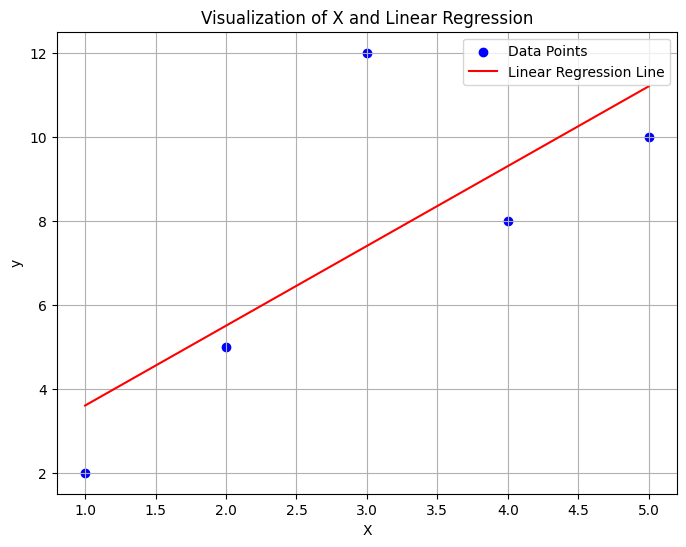

In [53]:
import matplotlib.pyplot as plt

# X 배열이 1차원인 경우를 대비하여 2차원 배열로 변환 (predict에 사용된 형태와 동일하게)
X_reshaped = X.reshape(-1, 1)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_reshaped, y, color='blue', label='Data Points')
plt.plot(X_reshaped, reg.predict(X_reshaped), color='red', linestyle='-', label='Linear Regression Line')
plt.title('Visualization of X and Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()